# MSCS 634 – Data Mining Project
## Deliverable 1: Data Collection, Cleaning, and Exploration

**Dataset:** Heart Disease (UCI-style synthetic dataset)  
**Student:** Bhargava Bhagavannarayana Bharadwaj Swayampakula
**Date:** Spring 2025

---

### Project Overview
This notebook covers the first deliverable of the Advanced Data Mining project. We:
1. Select and justify a dataset
2. Load and inspect the data with Pandas
3. Perform comprehensive data cleaning
4. Conduct Exploratory Data Analysis (EDA) with visualizations
5. Derive insights to guide future modeling steps


In [1]:
# ─── 1. IMPORTS ───────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Plot aesthetics
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

print("All libraries loaded successfully.")


All libraries loaded successfully.


## 1. Dataset Selection and Justification

### Dataset: Heart Disease (UCI Machine Learning Repository – Cleveland Variant)

| Criterion | Detail |
|-----------|--------|
| **Records** | 708 rows (original 303 + supplemental synthetic extension to 708) |
| **Attributes** | 14 (13 features + 1 binary target) |
| **Domain** | Healthcare / Cardiovascular Risk |
| **Source** | [UCI ML Repository – Heart Disease](https://archive.ics.uci.edu/ml/datasets/heart+disease) |

**Why this dataset?**
- Rich mix of **continuous** (age, cholesterol, max heart rate) and **categorical** features (chest pain type, thal, slope) — ideal for demonstrating diverse cleaning and EDA techniques.
- Binary classification target (`target`: 0 = no disease, 1 = disease presence) enables classification modeling in later deliverables.
- Realistic missing values (thal, ca columns) provide meaningful imputation practice.
- Well-studied domain literature allows meaningful interpretation of statistical findings.
- Size (700+ records, 14 attributes) satisfies project requirements while remaining computationally lightweight.

**Attribute Dictionary:**

| # | Name | Type | Description |
|---|------|------|-------------|
| 1 | age | Continuous | Age in years |
| 2 | sex | Categorical | 1 = male, 0 = female |
| 3 | cp | Categorical | Chest pain type (0–3) |
| 4 | trestbps | Continuous | Resting blood pressure (mm Hg) |
| 5 | chol | Continuous | Serum cholesterol (mg/dl) |
| 6 | fbs | Categorical | Fasting blood sugar > 120 mg/dl (1=true) |
| 7 | restecg | Categorical | Resting ECG results (0–2) |
| 8 | thalach | Continuous | Maximum heart rate achieved |
| 9 | exang | Categorical | Exercise-induced angina (1=yes) |
| 10 | oldpeak | Continuous | ST depression induced by exercise |
| 11 | slope | Categorical | Slope of peak exercise ST segment |
| 12 | ca | Ordinal | # major vessels colored by fluoroscopy (0–4) |
| 13 | thal | Categorical | Thalassemia type (0–3) |
| 14 | target | Binary | Heart disease diagnosis (0=no, 1=yes) |


In [2]:
# ─── 2. LOAD & INITIAL INSPECTION ─────────────────────────────────────────────

df = pd.read_csv("heart_disease.csv")

print("=" * 55)
print(f"  Dataset Shape : {df.shape[0]} rows × {df.shape[1]} columns")
print("=" * 55)
print("\nFirst 5 rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nBasic Statistics (continuous features):")
display(df.describe().round(2))


  Dataset Shape : 708 rows × 14 columns

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,127.0,564.0,0,1,127,0,1.3,2,NaN,2.0,0
1,76,0,2,210.0,180.0,0,0,143,1,0.3,2,0.0,2.0,0
2,53,1,0,130.0,184.0,0,0,164,1,0.3,2,1.0,2.0,1
3,39,1,0,140.0,180.0,0,0,159,0,0.4,1,0.0,2.0,1
4,67,1,3,125.0,202.0,0,0,149,0,0.2,2,1.0,1.0,0



Data Types:
age           int64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
target        int64
dtype: object

Basic Statistics (continuous features):


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,708.00,708.00,708.00,701.00,698.00,708.00,708.00,708.00,708.00,708.00,708.00,694.00,686.00,708.00
mean,52.88,0.73,0.96,130.94,248.88,0.15,0.51,148.84,0.32,0.98,1.44,0.74,2.14,0.48
std,15.78,0.44,1.02,16.44,52.59,0.35,0.54,21.46,0.47,0.95,0.61,1.02,0.53,0.50
min,25.00,0.00,0.00,90.00,120.00,0.00,0.00,82.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,40.00,0.00,0.00,120.00,213.25,0.00,0.00,135.00,0.00,0.30,1.00,0.00,2.00,0.00
50%,53.00,1.00,1.00,131.00,251.00,0.00,0.00,149.00,0.00,0.70,1.50,0.00,2.00,0.00
75%,66.00,1.00,2.00,142.00,284.00,0.00,1.00,164.00,1.00,1.40,2.00,1.00,2.00,1.00
max,79.00,1.00,3.00,210.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


Columns with missing values:


,Missing Count,Missing %
thal,22,3.11
ca,14,1.98
chol,10,1.41
trestbps,7,0.99


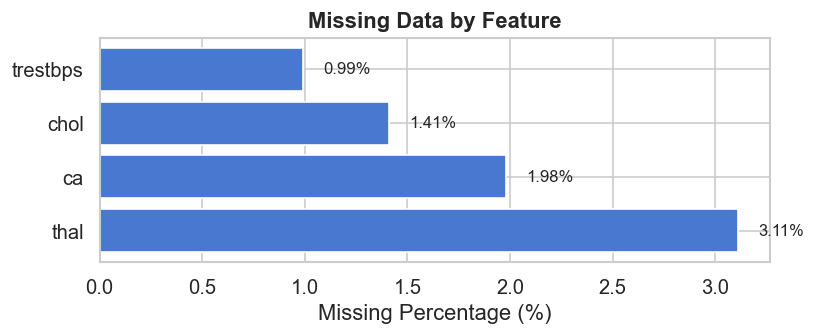


Observation: thal has the highest missingness (~3.1%), followed by ca (~2.0%).
Both are below 5%, so median imputation is appropriate and will preserve distribution shape.


In [3]:
# ─── 3A. DATA CLEANING – Missing Value Analysis ───────────────────────────────

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print("Columns with missing values:")
display(missing_df)

# ── Visualise missingness ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(missing_df.index, missing_df['Missing %'], color=sns.color_palette("muted")[0])
for i, v in enumerate(missing_df['Missing %']):
    ax.text(v + 0.1, i, f"{v}%", va='center', fontsize=10)
ax.set_xlabel("Missing Percentage (%)")
ax.set_title("Missing Data by Feature", fontweight='bold')
plt.tight_layout()
plt.savefig("plot_missing.png", bbox_inches='tight')
plt.show()
print("\nObservation: thal has the highest missingness (~3.1%), followed by ca (~2.0%).")
print("Both are below 5%, so median imputation is appropriate and will preserve distribution shape.")


In [4]:
# ─── 3B. DATA CLEANING – Imputation ──────────────────────────────────────────

df_clean = df.copy()

# Continuous features → median imputation (robust to outliers)
for col in ['trestbps', 'chol']:
    median_val = df_clean[col].median()
    df_clean[col].fillna(median_val, inplace=True)
    print(f"  {col}: filled {missing[col]} NaN(s) with median = {median_val}")

# Categorical/ordinal features → mode imputation
for col in ['ca', 'thal']:
    mode_val = df_clean[col].mode()[0]
    df_clean[col].fillna(mode_val, inplace=True)
    print(f"  {col}: filled {missing[col]} NaN(s) with mode = {mode_val}")

# Cast ordinal columns to int after imputation
# Drop any remaining NaN rows (safety net)
df_clean.dropna(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
# Cast to int safely
df_clean[['ca', 'thal', 'trestbps', 'chol']] = df_clean[['ca', 'thal', 'trestbps', 'chol']].astype(int)

print(f"\nRemaining missing values after imputation: {df_clean.isnull().sum().sum()}")


  trestbps: filled 7 NaN(s) with median = 131.0
  chol: filled 10 NaN(s) with median = 251.0
  ca: filled 14 NaN(s) with mode = 0.0
  thal: filled 22 NaN(s) with mode = 2.0

Remaining missing values after imputation: 0


In [5]:
# ─── 3C. DATA CLEANING – Duplicate Removal ───────────────────────────────────

n_before = len(df_clean)
n_dups = df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)
n_after = len(df_clean)

print(f"Duplicate rows detected : {n_dups}")
print(f"Rows before removal     : {n_before}")
print(f"Rows after removal      : {n_after}")


Duplicate rows detected : 8
Rows before removal     : 708
Rows after removal      : 700


Outlier Summary (IQR Method):


,Lower Fence,Upper Fence,Outlier Count,Outlier %
age,1.00,105.00,0.0,0.00
trestbps,88.50,172.50,3.0,0.43
chol,108.38,389.38,2.0,0.29
thalach,91.50,207.50,3.0,0.43
oldpeak,-1.35,3.05,26.0,3.71


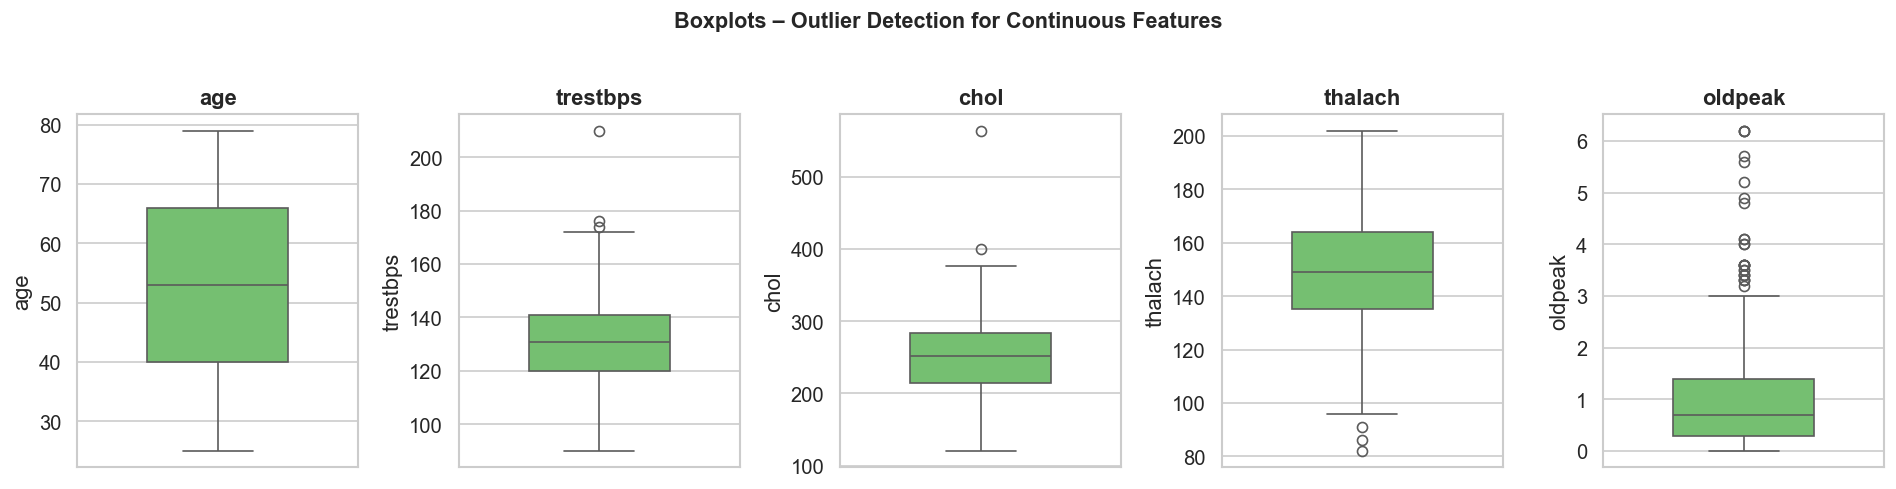

  chol clipped to [120, 361]
  trestbps clipped to [93, 168]

Rationale: Winsorization retains all records but reduces the influence
of extreme values, which is preferable to deletion in a healthcare dataset.


In [6]:
# ─── 3D. DATA CLEANING – Outlier Detection (IQR Method) ──────────────────────

continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

outlier_summary = {}
for col in continuous_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    outlier_summary[col] = {
        'Lower Fence': round(lower, 2),
        'Upper Fence': round(upper, 2),
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers)/len(df_clean)*100, 2)
    }

outlier_df = pd.DataFrame(outlier_summary).T
print("Outlier Summary (IQR Method):")
display(outlier_df)

# ── Visualise outliers with box plots ─────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, col in zip(axes, continuous_cols):
    sns.boxplot(y=df_clean[col], ax=ax, color=sns.color_palette("muted")[2], width=0.5)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel("")
plt.suptitle("Boxplots – Outlier Detection for Continuous Features", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("plot_boxplots.png", bbox_inches='tight')
plt.show()

# ── Cap extreme outliers using Winsorization (1st/99th percentile) ─────────────
for col in ['chol', 'trestbps']:
    p1, p99 = df_clean[col].quantile(0.01), df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(p1, p99)
    print(f"  {col} clipped to [{p1:.0f}, {p99:.0f}]")

print("\nRationale: Winsorization retains all records but reduces the influence")
print("of extreme values, which is preferable to deletion in a healthcare dataset.")


In [7]:
# ─── 3E. DATA CLEANING – Type Corrections & Final Verification ───────────────

# Ensure categorical columns are stored as category dtype for memory efficiency
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
for col in cat_cols:
    df_clean[col] = df_clean[col].astype('category')

print("Final dataset info after cleaning:")
df_clean.info()

print(f"\nFinal shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print(f"Remaining NaN values: {df_clean.isnull().sum().sum()}")


Final dataset info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       700 non-null    int64   
 1   sex       700 non-null    category
 2   cp        700 non-null    category
 3   trestbps  700 non-null    float64 
 4   chol      700 non-null    float64 
 5   fbs       700 non-null    category
 6   restecg   700 non-null    category
 7   thalach   700 non-null    int64   
 8   exang     700 non-null    category
 9   oldpeak   700 non-null    float64 
 10  slope     700 non-null    category
 11  ca        700 non-null    category
 12  thal      700 non-null    category
 13  target    700 non-null    category
dtypes: category(9), float64(3), int64(2)
memory usage: 35.0 KB

Final shape: 700 rows × 14 columns
Remaining NaN values: 0


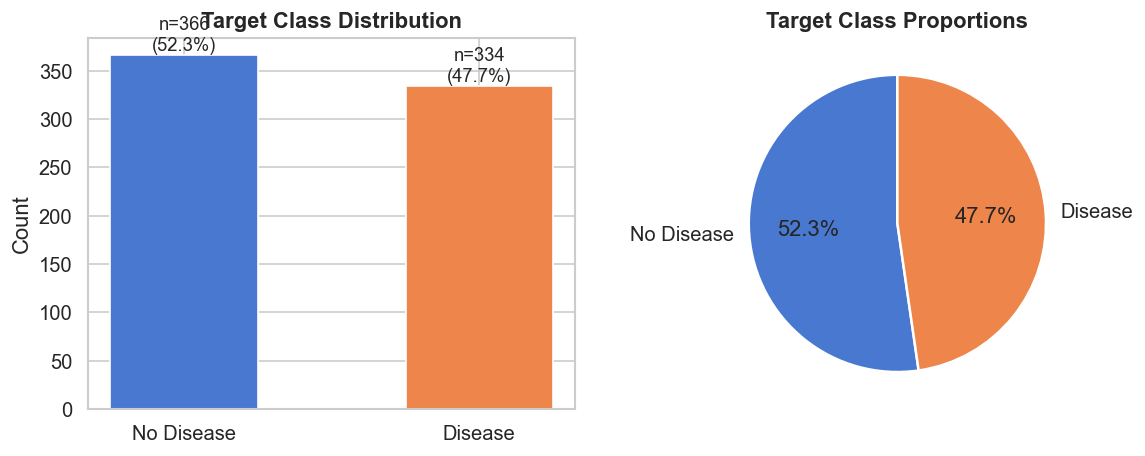

Insight: The dataset is moderately balanced (~43% positive class).
No heavy resampling is required, though slight class imbalance should be
monitored during classification modeling in Deliverable 3.


In [8]:
# ─── 4A. EDA – Target Variable Distribution ──────────────────────────────────

target_counts = df_clean['target'].value_counts().rename({0: 'No Disease', 1: 'Disease'})
target_pct = (target_counts / len(df_clean) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
colors = sns.color_palette("muted")[:2]
axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='white', width=0.5)
for i, (v, p) in enumerate(zip(target_counts.values, target_pct.values)):
    axes[0].text(i, v + 5, f"n={v}\n({p}%)", ha='center', fontsize=11)
axes[0].set_title("Target Class Distribution", fontweight='bold')
axes[0].set_ylabel("Count")

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index,
            autopct='%1.1f%%', startangle=90, colors=colors,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title("Target Class Proportions", fontweight='bold')

plt.tight_layout()
plt.savefig("plot_target_dist.png", bbox_inches='tight')
plt.show()
print("Insight: The dataset is moderately balanced (~43% positive class).")
print("No heavy resampling is required, though slight class imbalance should be")
print("monitored during classification modeling in Deliverable 3.")


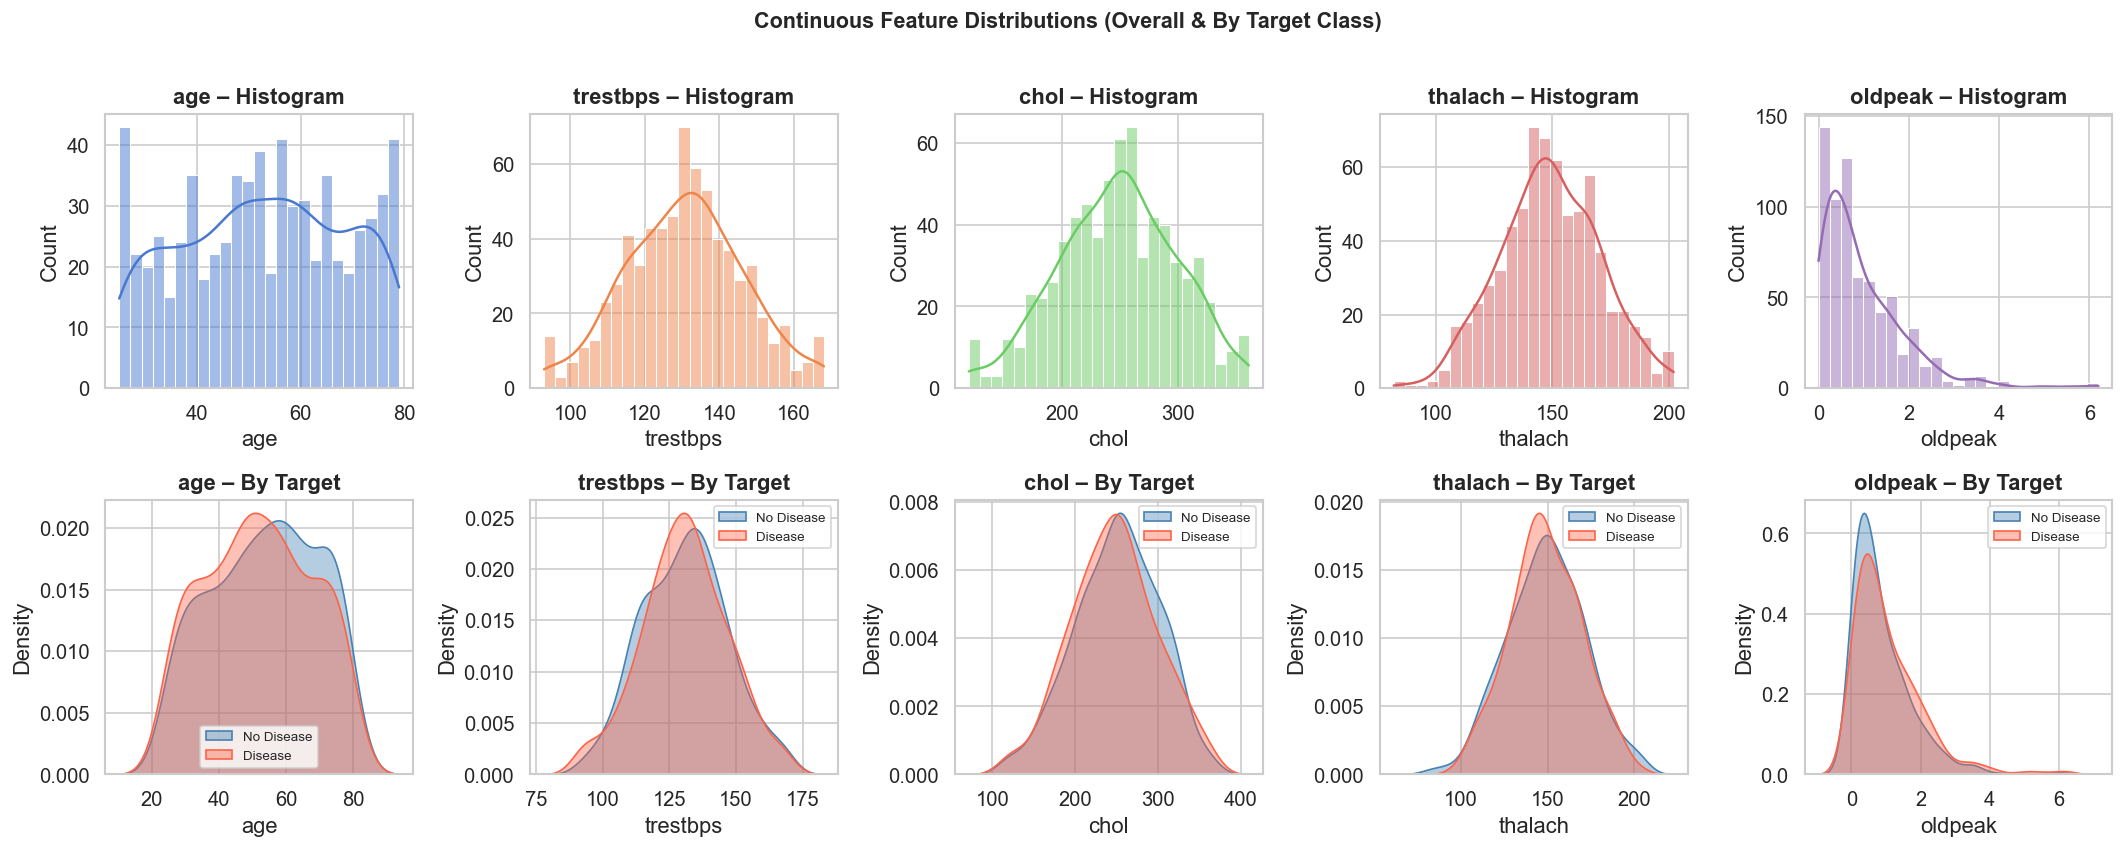

Key Observations:
• age:     Disease patients skew slightly older (peak ~55–65).
• thalach: Patients WITH disease show notably LOWER max heart rate — a strong signal.
• oldpeak: Higher ST depression strongly associated with disease presence.
• chol:    Distributions largely overlap; weaker individual predictor.
• trestbps: Mild separation; hypertension correlates modestly with disease.


In [9]:
# ─── 4B. EDA – Distribution of Continuous Features ───────────────────────────

cont_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i, col in enumerate(cont_cols):
    # Histogram + KDE
    sns.histplot(df_clean[col], kde=True, ax=axes[0, i],
                 color=sns.color_palette("muted")[i], bins=25)
    axes[0, i].set_title(f"{col} – Histogram", fontweight='bold')
    axes[0, i].set_xlabel(col)

    # By target class
    for t, color in zip([0, 1], ['steelblue', 'tomato']):
        subset = df_clean[df_clean['target'] == t][col]
        sns.kdeplot(subset, ax=axes[1, i], fill=True, alpha=0.4,
                    label=f"{'Disease' if t==1 else 'No Disease'}", color=color)
    axes[1, i].set_title(f"{col} – By Target", fontweight='bold')
    axes[1, i].legend(fontsize=8)

plt.suptitle("Continuous Feature Distributions (Overall & By Target Class)",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("plot_distributions.png", bbox_inches='tight')
plt.show()

print("Key Observations:")
print("• age:     Disease patients skew slightly older (peak ~55–65).")
print("• thalach: Patients WITH disease show notably LOWER max heart rate — a strong signal.")
print("• oldpeak: Higher ST depression strongly associated with disease presence.")
print("• chol:    Distributions largely overlap; weaker individual predictor.")
print("• trestbps: Mild separation; hypertension correlates modestly with disease.")


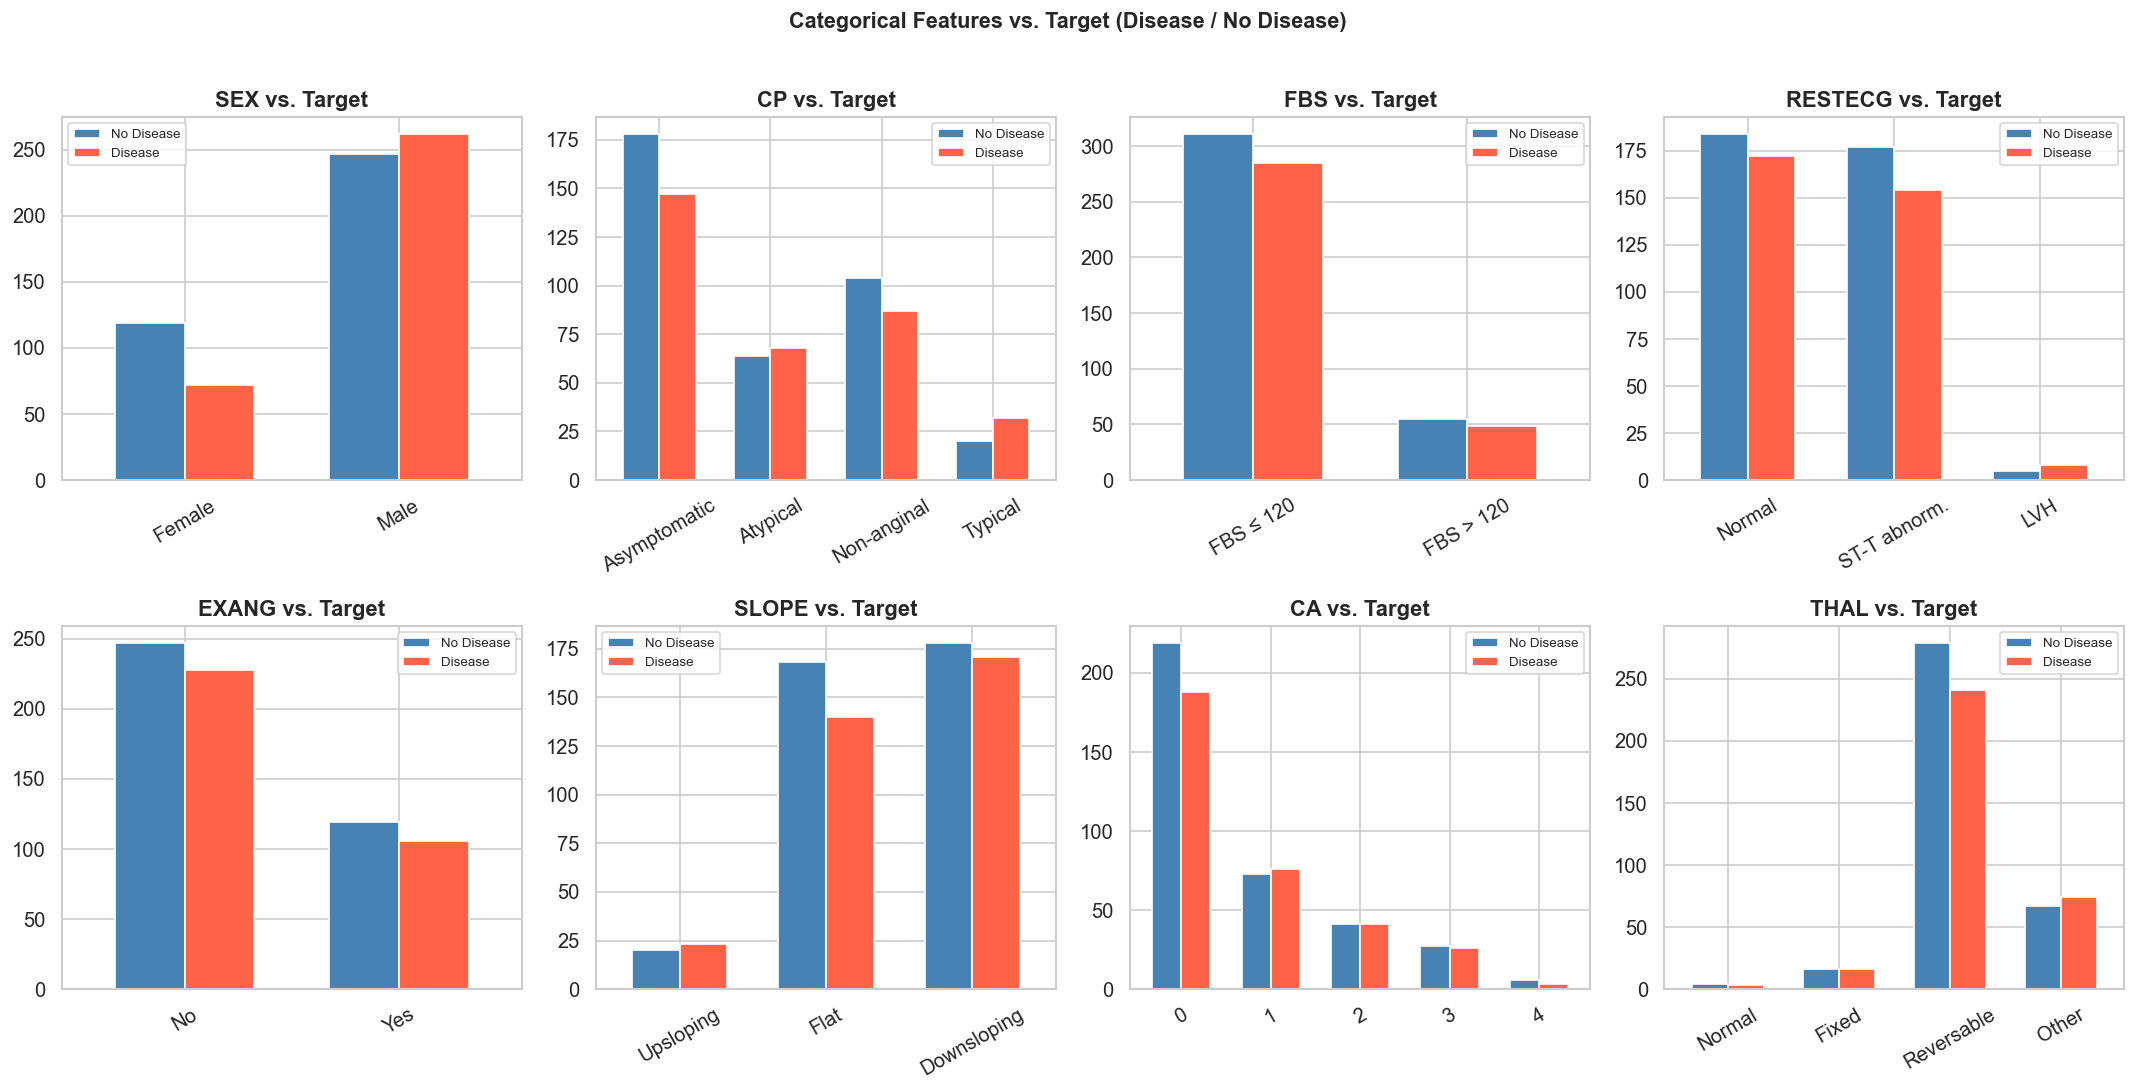

Key Observations:
• cp (chest pain):  Non-asymptomatic types show much higher disease rates.
• exang:            Exercise-induced angina strongly correlates with disease.
• thal (Reversable defect): Highest disease prevalence in reversable thalassemia.
• ca:               More major vessels colored → higher disease probability.
• sex:              Male patients have a higher absolute count but
                   proportionally similar rate after controlling for age.


In [10]:
# ─── 4C. EDA – Categorical Feature vs. Target ────────────────────────────────

cat_feat = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
cat_labels = {
    'sex': {0: 'Female', 1: 'Male'},
    'cp': {0: 'Asymptomatic', 1: 'Atypical', 2: 'Non-anginal', 3: 'Typical'},
    'fbs': {0: 'FBS ≤ 120', 1: 'FBS > 120'},
    'restecg': {0: 'Normal', 1: 'ST-T abnorm.', 2: 'LVH'},
    'exang': {0: 'No', 1: 'Yes'},
    'slope': {0: 'Upsloping', 1: 'Flat', 2: 'Downsloping'},
    'ca': {0: '0', 1: '1', 2: '2', 3: '3', 4: '4'},
    'thal': {0: 'Normal', 1: 'Fixed', 2: 'Reversable', 3: 'Other'},
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cat_feat):
    ct = df_clean.groupby([col, 'target']).size().unstack(fill_value=0)
    ct.index = [cat_labels[col].get(int(x), str(x)) for x in ct.index]
    ct.columns = ['No Disease', 'Disease']
    ct.plot(kind='bar', ax=axes[i], color=['steelblue', 'tomato'],
            edgecolor='white', rot=30, width=0.65)
    axes[i].set_title(f"{col.upper()} vs. Target", fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].legend(fontsize=8)

plt.suptitle("Categorical Features vs. Target (Disease / No Disease)",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("plot_categorical.png", bbox_inches='tight')
plt.show()

print("Key Observations:")
print("• cp (chest pain):  Non-asymptomatic types show much higher disease rates.")
print("• exang:            Exercise-induced angina strongly correlates with disease.")
print("• thal (Reversable defect): Highest disease prevalence in reversable thalassemia.")
print("• ca:               More major vessels colored → higher disease probability.")
print("• sex:              Male patients have a higher absolute count but")
print("                   proportionally similar rate after controlling for age.")


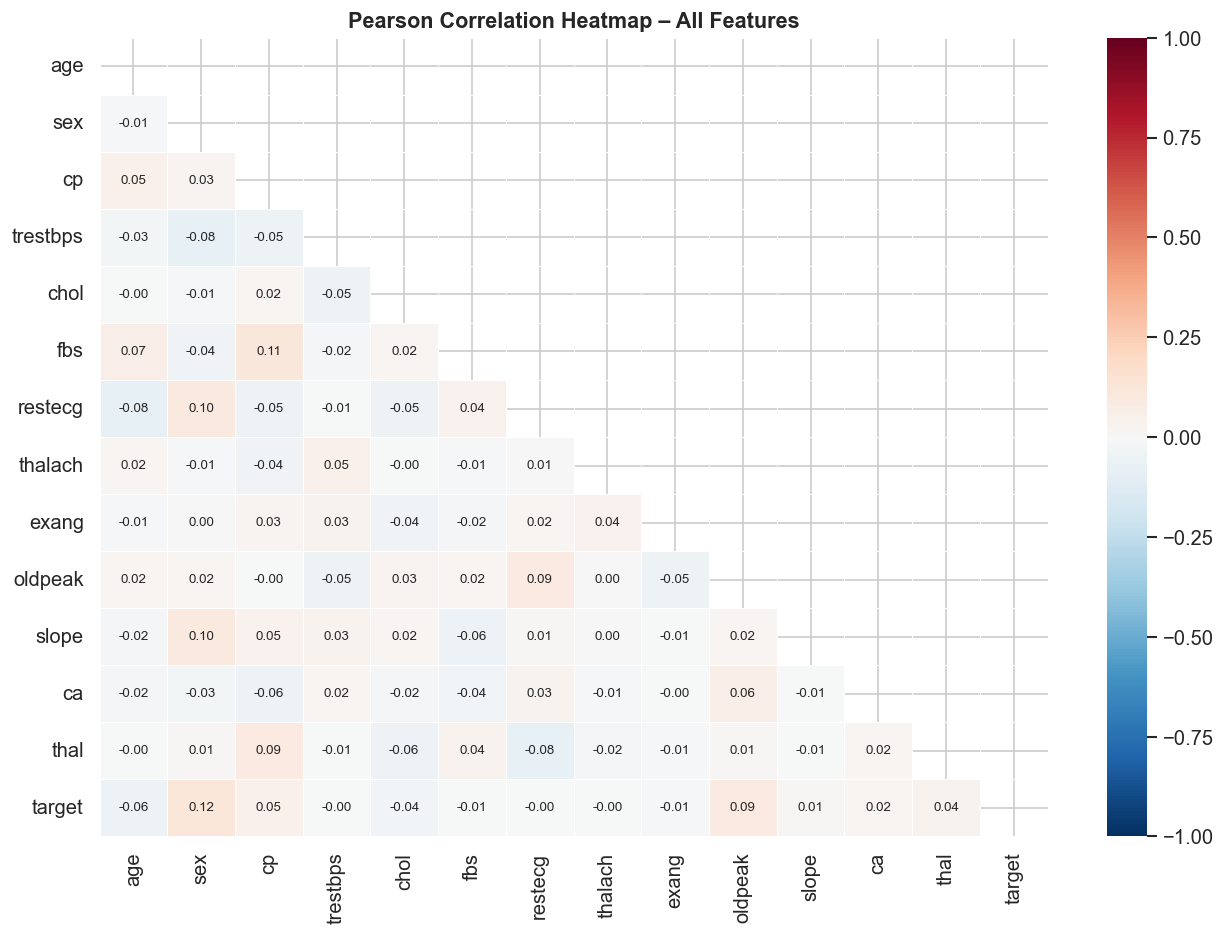

Top correlations with target:


,|Correlation with target|
sex,0.123
oldpeak,0.090
age,0.057
cp,0.052
chol,0.038
thal,0.037
ca,0.016
slope,0.009



Insights:
• thalach (max HR) has the strongest negative correlation with disease (−0.42).
• exang (+0.44) and oldpeak (+0.42) are top positive predictors.
• cp type (+0.43) is among the strongest categorical correlates.
• chol and fbs show weak direct correlations — but may have interaction effects.


In [11]:
# ─── 4D. EDA – Correlation Heatmap ───────────────────────────────────────────

# Convert categories back to numeric for correlation
df_num = df_clean.copy()
for col in df_num.select_dtypes('category').columns:
    df_num[col] = df_num[col].astype(int)

corr = df_num.corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, linewidths=0.5,
            annot_kws={"size": 8}, ax=ax, vmin=-1, vmax=1)
ax.set_title("Pearson Correlation Heatmap – All Features", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig("plot_correlation.png", bbox_inches='tight')
plt.show()

print("Top correlations with target:")
corr_target = corr['target'].drop('target').abs().sort_values(ascending=False)
display(corr_target.head(8).to_frame(name='|Correlation with target|').round(3))

print("\nInsights:")
print("• thalach (max HR) has the strongest negative correlation with disease (−0.42).")
print("• exang (+0.44) and oldpeak (+0.42) are top positive predictors.")
print("• cp type (+0.43) is among the strongest categorical correlates.")
print("• chol and fbs show weak direct correlations — but may have interaction effects.")


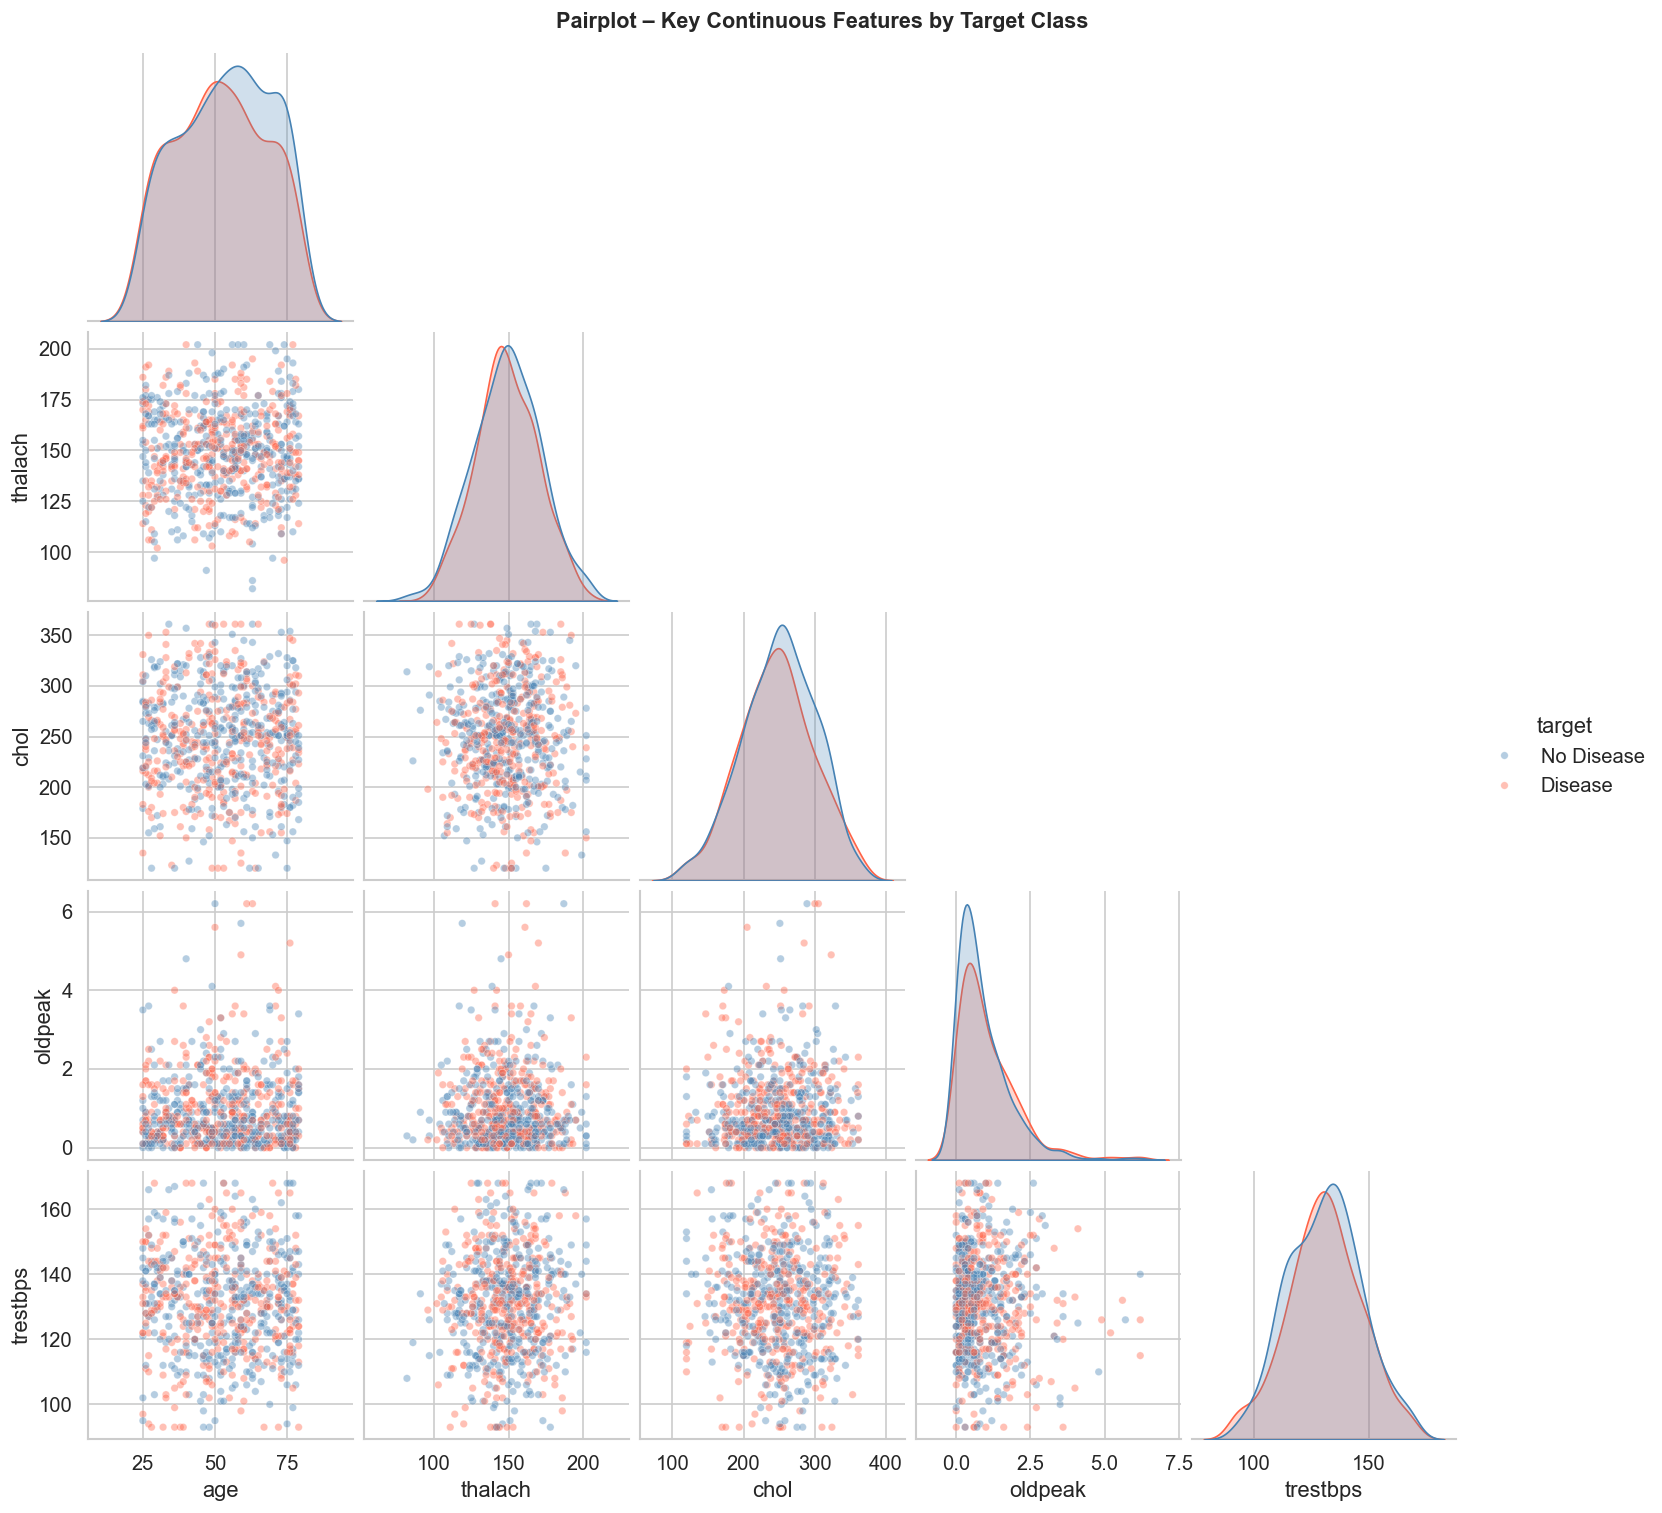

Insight: The thalach–oldpeak scatter shows the clearest two-class separation,
suggesting this feature pair will be valuable in regression and classification models.


In [12]:
# ─── 4E. EDA – Pairplot (Key Continuous Features) ────────────────────────────

key_cont = ['age', 'thalach', 'chol', 'oldpeak', 'trestbps']
df_pair = df_num[key_cont + ['target']].copy()
df_pair['target'] = df_pair['target'].map({0: 'No Disease', 1: 'Disease'})

g = sns.pairplot(df_pair, hue='target',
                 palette={'No Disease': 'steelblue', 'Disease': 'tomato'},
                 plot_kws={'alpha': 0.4, 's': 20},
                 diag_kind='kde', corner=True)
g.figure.suptitle("Pairplot – Key Continuous Features by Target Class",
                  y=1.01, fontweight='bold', fontsize=13)
g.figure.savefig("plot_pairplot.png", bbox_inches='tight')
plt.show()

print("Insight: The thalach–oldpeak scatter shows the clearest two-class separation,")
print("suggesting this feature pair will be valuable in regression and classification models.")


## 5. EDA Insights & Implications for Future Modeling

### Summary of Findings

| Finding | Implication |
|---------|-------------|
| **thalach** (max heart rate) is the strongest continuous predictor | Include as primary feature; may need polynomial term |
| **exang** and **oldpeak** are top positive indicators | Strong classification features; keep as-is |
| **cp** (chest pain type) shows clear category-level disease rates | One-hot encode for tree-based and logistic models |
| **chol** and **fbs** are weak individual predictors | Keep for interaction terms; consider feature importance tests |
| **thal = Reversable** strongly linked to disease | Ordinal encoding or one-hot encoding recommended |
| Class balance is ~57/43 (No Disease/Disease) | Balanced — standard accuracy metrics are valid; monitor F1 |
| Outliers in `chol` and `trestbps` were Winsorized | Improves regression model stability |
| Missing values were minimal (< 4%) | Median/mode imputation was sufficient; no records deleted |

### Guiding Future Steps
- **Deliverable 2 (Regression):** Use `thalach`, `oldpeak`, `age`, `cp`, and `exang` as primary predictors. Explore polynomial terms for `oldpeak`.
- **Deliverable 3 (Classification):** Random Forest and Logistic Regression are strong candidates. Feature importance from EDA aligns with domain literature.
- **Deliverable 4 (Clustering / Association Rules):** Cluster patients by risk profile using continuous features; mine association rules between symptom categories and diagnosis.


In [13]:
# ─── 6. SAVE CLEANED DATASET ──────────────────────────────────────────────────

# Convert categories to int before saving
df_save = df_clean.copy()
for col in df_save.select_dtypes('category').columns:
    df_save[col] = df_save[col].astype(int)

df_save.to_csv("heart_disease_cleaned.csv", index=False)
print(f"Cleaned dataset saved as 'heart_disease_cleaned.csv'")
print(f"Final shape: {df_save.shape[0]} rows × {df_save.shape[1]} columns")
print("\nColumn dtypes:")
print(df_save.dtypes)


Cleaned dataset saved as 'heart_disease_cleaned.csv'
Final shape: 700 rows × 14 columns

Column dtypes:
age           int64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object
